# LSTM 기반 F1 피트스탑 예측 모델

**목표**: 드라이버가 다음 랩에 피트스탑을 할지 예측 (이진 분류)  
**접근**: (Driver, Race, Year)별 랩 시퀀스를 LSTM으로 처리  
**특징**: Gap-aware 시퀀스 (비연속 랩 간격 인코딩)

In [21]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


## 1. 데이터 로딩 및 시퀀스 구성

In [22]:
data_path = './data/kaggle_data/'
train = pd.read_csv(data_path + 'train.csv')
test = pd.read_csv(data_path + 'test.csv')
submission = pd.read_csv(data_path + 'sample_submission.csv')

print(f'Train: {train.shape}, Test: {test.shape}')
print(f'Target 분포:\n{train["PitNextLap"].value_counts(normalize=True)}')

Train: (439140, 16), Test: (188165, 15)
Target 분포:
PitNextLap
0.0    0.801018
1.0    0.198982
Name: proportion, dtype: float64


In [23]:
# Train/Test 합치고 시퀀스 구성
train['is_train'] = True
test['is_train'] = False
test['PitNextLap'] = -1  # placeholder

combined = pd.concat([train, test], ignore_index=True)
combined = combined.sort_values(['Driver', 'Race', 'Year', 'LapNumber']).reset_index(drop=True)

# LapGap: 같은 그룹 내 이전 행과의 랩 간격
combined['LapGap'] = combined.groupby(['Driver', 'Race', 'Year'])['LapNumber'].diff().fillna(1.0)

print(f'Combined: {combined.shape}')
print(f'그룹 수: {combined.groupby(["Driver", "Race", "Year"]).ngroups}')
print(f'그룹별 평균 시퀀스 길이: {combined.groupby(["Driver", "Race", "Year"]).size().mean():.1f}')

Combined: (627305, 18)
그룹 수: 42233
그룹별 평균 시퀀스 길이: 14.9


## 2. 피처 인코딩

In [24]:
# 범주형 피처 인코딩
cat_features = ['Driver', 'Compound', 'Race']
cat_encoders = {}
cat_dims = []  # 각 범주형 피처의 고유값 수
cat_emb_dims = []  # 임베딩 차원

emb_dim_map = {'Driver': 32, 'Compound': 4, 'Race': 8}

for col in cat_features:
    le = LabelEncoder()
    combined[col + '_enc'] = le.fit_transform(combined[col])
    cat_encoders[col] = le
    n_unique = len(le.classes_)
    cat_dims.append(n_unique)
    cat_emb_dims.append(emb_dim_map[col])
    print(f'{col}: {n_unique} unique → embedding dim {emb_dim_map[col]}')

# 연속형 피처
cont_features = [
    'Year', 'LapNumber', 'Stint', 'TyreLife', 'Position',
    'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
    'RaceProgress', 'Position_Change', 'PitStop', 'LapGap'
]

# StandardScaler (train 데이터로만 fit)
scaler = StandardScaler()
train_mask = combined['is_train'].values
scaler.fit(combined.loc[train_mask, cont_features])
combined[cont_features] = scaler.transform(combined[cont_features])

n_continuous = len(cont_features)
total_input_dim = sum(cat_emb_dims) + n_continuous
print(f'\n연속형 피처: {n_continuous}개')
print(f'총 입력 차원: {total_input_dim} (임베딩 {sum(cat_emb_dims)} + 연속형 {n_continuous})')

Driver: 887 unique → embedding dim 32
Compound: 5 unique → embedding dim 4
Race: 26 unique → embedding dim 8

연속형 피처: 12개
총 입력 차원: 56 (임베딩 44 + 연속형 12)


## 3. Dataset & DataLoader

In [25]:
class F1SequenceDataset(Dataset):
    """각 샘플 = (Driver, Race, Year) 그룹의 전체 랩 시퀀스"""
    
    def __init__(self, df, cat_enc_cols, cont_cols):
        self.groups = []
        grouped = df.groupby(['Driver', 'Race', 'Year'])
        
        for _, group in grouped:
            cat_vals = torch.LongTensor(group[cat_enc_cols].values)
            cont_vals = torch.FloatTensor(group[cont_cols].values)
            targets = torch.FloatTensor(group['PitNextLap'].values)
            is_train = torch.BoolTensor(group['is_train'].values)
            ids = group['id'].values.tolist()
            
            self.groups.append({
                'cat': cat_vals,
                'cont': cont_vals,
                'target': targets,
                'is_train': is_train,
                'ids': ids,
                'length': len(group)
            })
    
    def __len__(self):
        return len(self.groups)
    
    def __getitem__(self, idx):
        g = self.groups[idx]
        return g['cat'], g['cont'], g['target'], g['is_train'], g['ids'], g['length']


def collate_fn(batch):
    batch.sort(key=lambda x: x[-1], reverse=True)
    cats, conts, targets, masks, ids_list, lengths = zip(*batch)
    
    cats_padded = pad_sequence(cats, batch_first=True, padding_value=0)
    conts_padded = pad_sequence(conts, batch_first=True, padding_value=0.0)
    targets_padded = pad_sequence(targets, batch_first=True, padding_value=-1.0)
    masks_padded = pad_sequence(masks, batch_first=True, padding_value=False)
    
    return cats_padded, conts_padded, targets_padded, masks_padded, ids_list, list(lengths)


cat_enc_cols = [col + '_enc' for col in cat_features]
print(f'범주형 인코딩 컬럼: {cat_enc_cols}')
print(f'연속형 컬럼: {cont_features}')

범주형 인코딩 컬럼: ['Driver_enc', 'Compound_enc', 'Race_enc']
연속형 컬럼: ['Year', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitStop', 'LapGap']


## 4. LSTM 모델 정의

In [26]:
class PitStopLSTM(nn.Module):
    def __init__(self, cat_dims, cat_emb_dims, n_continuous,
                 hidden_size=128, n_layers=2, dropout=0.3):
        super().__init__()
        
        self.embeddings = nn.ModuleList([
            nn.Embedding(n_cats, emb_dim)
            for n_cats, emb_dim in zip(cat_dims, cat_emb_dims)
        ])
        
        total_emb = sum(cat_emb_dims)
        input_dim = total_emb + n_continuous
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
            bidirectional=False
        )
        
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, 1)
        )
    
    def forward(self, cat_feats, cont_feats, lengths):
        # 임베딩
        embs = [emb(cat_feats[:, :, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(embs + [cont_feats], dim=-1)
        
        # LSTM
        packed = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=True)
        packed_out, _ = self.lstm(packed)
        output, _ = pad_packed_sequence(packed_out, batch_first=True)
        
        # 분류 헤드 (각 타임스텝별)
        logits = self.head(output).squeeze(-1)
        return logits


model = PitStopLSTM(cat_dims, cat_emb_dims, n_continuous, hidden_size=128, n_layers=2, dropout=0.3)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'총 파라미터: {total_params:,}')
print(f'학습 가능 파라미터: {trainable_params:,}')
print(model)

총 파라미터: 264,517
학습 가능 파라미터: 264,517
PitStopLSTM(
  (embeddings): ModuleList(
    (0): Embedding(887, 32)
    (1): Embedding(5, 4)
    (2): Embedding(26, 8)
  )
  (lstm): LSTM(56, 128, num_layers=2, batch_first=True, dropout=0.3)
  (head): Sequential(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.15, inplace=False)
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 5. Train/Validation 분할 및 데이터 준비

In [27]:
# Train 데이터에서 GroupKFold로 train/val 분할
# 그룹 = Race + Year (같은 레이스의 모든 랩이 같은 fold에)
train_only = combined[combined['is_train']].copy()
train_only['group'] = train_only['Race'] + '_' + train_only['Year'].astype(str)

gkf = GroupKFold(n_splits=5)
groups = train_only['group'].values

# Fold 0을 validation으로 사용
for fold, (train_idx, val_idx) in enumerate(gkf.split(train_only, groups=groups)):
    if fold == 0:
        train_ids = set(train_only.iloc[train_idx]['id'].values)
        val_ids = set(train_only.iloc[val_idx]['id'].values)
        break

print(f'Train 행: {len(train_ids):,}')
print(f'Val 행: {len(val_ids):,}')

# combined에 fold 정보 추가
combined['fold'] = 'test'
combined.loc[combined['id'].isin(train_ids), 'fold'] = 'train'
combined.loc[combined['id'].isin(val_ids), 'fold'] = 'val'
print(f'\nFold 분포:\n{combined["fold"].value_counts()}')

Train 행: 351,122
Val 행: 88,018

Fold 분포:
fold
train    351122
test     188165
val       88018
Name: count, dtype: int64


In [28]:
# 학습용 Dataset: val 행을 test처럼 취급 (마스크 처리)
# → 학습 시 train fold 행만 loss 계산, val fold 행은 예측만 추출

# 학습용: val을 마스크 처리
train_combined = combined.copy()
train_combined.loc[train_combined['fold'] == 'val', 'is_train'] = False

# 학습용 Dataset (train+val 시퀀스 포함)
train_dataset = F1SequenceDataset(train_combined, cat_enc_cols, cont_features)

# 전체 Dataset (최종 추론용)
full_dataset = F1SequenceDataset(combined, cat_enc_cols, cont_features)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, collate_fn=collate_fn)
full_loader = DataLoader(full_dataset, batch_size=256, shuffle=False, collate_fn=collate_fn)

print(f'Train Dataset 그룹 수: {len(train_dataset)}')
print(f'Full Dataset 그룹 수: {len(full_dataset)}')

Train Dataset 그룹 수: 42233
Full Dataset 그룹 수: 42233


## 6. 학습 및 평가 함수

In [29]:
# 클래스 불균형 보정 (pos_weight ≈ neg/pos ratio)
pos_rate = train['PitNextLap'].mean()
pos_weight = torch.tensor([(1 - pos_rate) / pos_rate], dtype=torch.float32).to(device)
print(f'Positive rate: {pos_rate:.3f}, pos_weight: {pos_weight.item():.2f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='none')


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    n_batches = 0
    
    for cats, conts, targets, masks, ids_list, lengths in loader:
        cats = cats.to(device)
        conts = conts.to(device)
        targets = targets.to(device)
        masks = masks.to(device)
        
        logits = model(cats, conts, lengths)
        
        # train 위치에서만 loss 계산
        loss_all = criterion(logits, targets)
        mask_float = masks.float()
        
        if mask_float.sum() == 0:
            continue
        
        loss = (loss_all * mask_float).sum() / mask_float.sum()
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        n_batches += 1
    
    return total_loss / max(n_batches, 1)


def evaluate(model, loader, val_ids, device):
    """val_ids에 해당하는 행의 예측만 추출하여 AUC 계산"""
    model.eval()
    predictions = {}
    
    with torch.no_grad():
        for cats, conts, targets, masks, ids_list, lengths in loader:
            cats = cats.to(device)
            conts = conts.to(device)
            
            logits = model(cats, conts, lengths)
            probs = torch.sigmoid(logits)
            
            for i in range(len(lengths)):
                for t in range(lengths[i]):
                    row_id = ids_list[i][t]
                    if row_id in val_ids:
                        predictions[row_id] = probs[i, t].item()
    
    # val 데이터의 실제 타겟과 비교
    val_df = combined[combined['id'].isin(val_ids)][['id', 'PitNextLap']]
    val_df = val_df.set_index('id')
    
    y_true = []
    y_pred = []
    for row_id, prob in predictions.items():
        y_true.append(val_df.loc[row_id, 'PitNextLap'])
        y_pred.append(prob)
    
    auc = roc_auc_score(y_true, y_pred)
    
    # F1 (threshold=0.5)
    y_pred_binary = [1 if p > 0.5 else 0 for p in y_pred]
    f1 = f1_score(y_true, y_pred_binary)
    
    return auc, f1, y_true, y_pred


print('학습/평가 함수 정의 완료')

Positive rate: 0.199, pos_weight: 4.03
학습/평가 함수 정의 완료


In [30]:
## 7. 모델 학습

In [31]:
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

n_epochs = 30
patience = 5
best_auc = 0
best_epoch = 0
no_improve = 0

history = {'loss': [], 'auc': [], 'f1': []}

for epoch in range(n_epochs):
    # 학습
    loss = train_epoch(model, train_loader, optimizer, criterion, device)
    scheduler.step()
    
    # 평가 (train_loader에서 val 위치 추출)
    auc, f1, _, _ = evaluate(model, train_loader, val_ids, device)
    
    history['loss'].append(loss)
    history['auc'].append(auc)
    history['f1'].append(f1)
    
    lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch+1:02d}/{n_epochs} | Loss: {loss:.4f} | AUC: {auc:.4f} | F1: {f1:.4f} | LR: {lr:.6f}')
    
    # Early stopping
    if auc > best_auc:
        best_auc = auc
        best_epoch = epoch + 1
        no_improve = 0
        torch.save(model.state_dict(), 'best_lstm.pth')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch+1}. Best AUC: {best_auc:.4f} at epoch {best_epoch}')
            break

print(f'\n최종 Best AUC: {best_auc:.4f} (Epoch {best_epoch})')

Epoch 01/30 | Loss: 0.7429 | AUC: 0.8460 | F1: 0.6046 | LR: 0.000997
Epoch 02/30 | Loss: 0.6031 | AUC: 0.8647 | F1: 0.6310 | LR: 0.000989
Epoch 03/30 | Loss: 0.5714 | AUC: 0.8740 | F1: 0.6528 | LR: 0.000976
Epoch 04/30 | Loss: 0.5536 | AUC: 0.8585 | F1: 0.6265 | LR: 0.000957
Epoch 05/30 | Loss: 0.5425 | AUC: 0.8584 | F1: 0.6317 | LR: 0.000933
Epoch 06/30 | Loss: 0.5324 | AUC: 0.8507 | F1: 0.6139 | LR: 0.000905
Epoch 07/30 | Loss: 0.5252 | AUC: 0.8711 | F1: 0.6344 | LR: 0.000872
Epoch 08/30 | Loss: 0.5177 | AUC: 0.8584 | F1: 0.6311 | LR: 0.000835

Early stopping at epoch 8. Best AUC: 0.8740 at epoch 3

최종 Best AUC: 0.8740 (Epoch 3)


## 8. 학습 결과 시각화

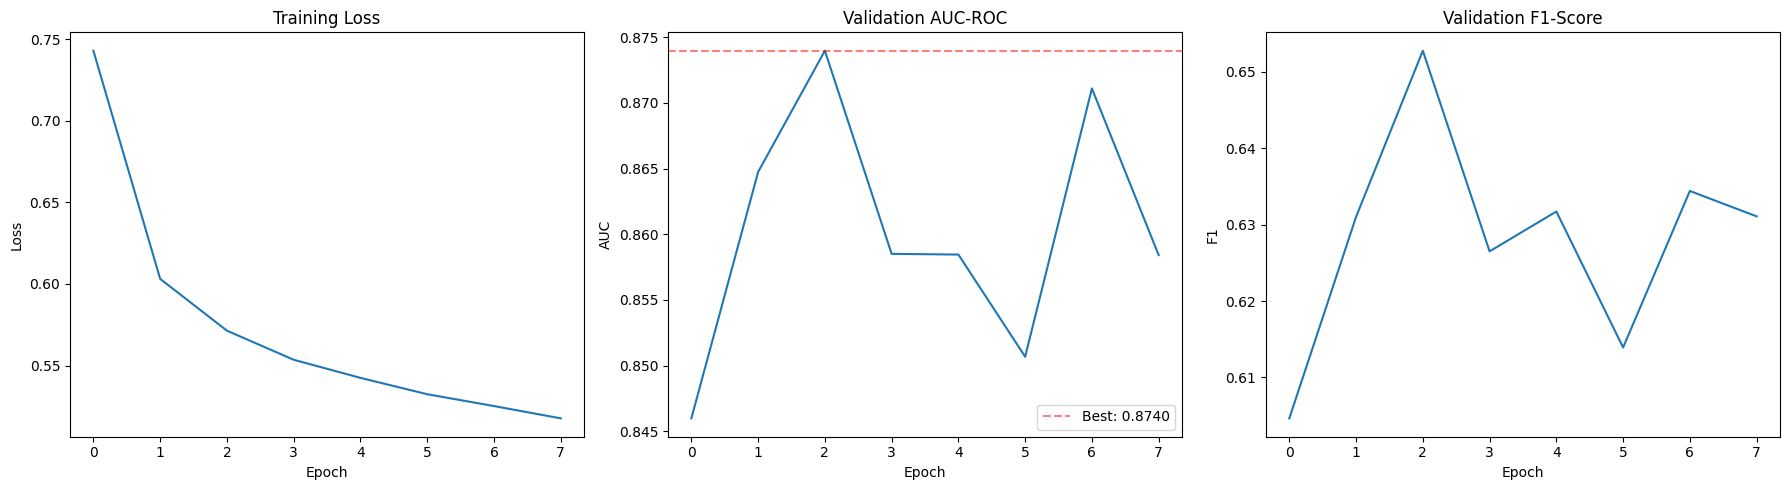

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['loss'])
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(history['auc'])
axes[1].set_title('Validation AUC-ROC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].axhline(y=best_auc, color='r', linestyle='--', alpha=0.5, label=f'Best: {best_auc:.4f}')
axes[1].legend()

axes[2].plot(history['f1'])
axes[2].set_title('Validation F1-Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1')

plt.tight_layout()
plt.show()

## 9. Validation 상세 평가

Best Model Validation Results:
  AUC-ROC: 0.8740
  F1-Score: 0.6528

Classification Report:
              precision    recall  f1-score   support

      No Pit       0.95      0.80      0.87     69259
         Pit       0.53      0.85      0.65     18759

    accuracy                           0.81     88018
   macro avg       0.74      0.82      0.76     88018
weighted avg       0.86      0.81      0.82     88018



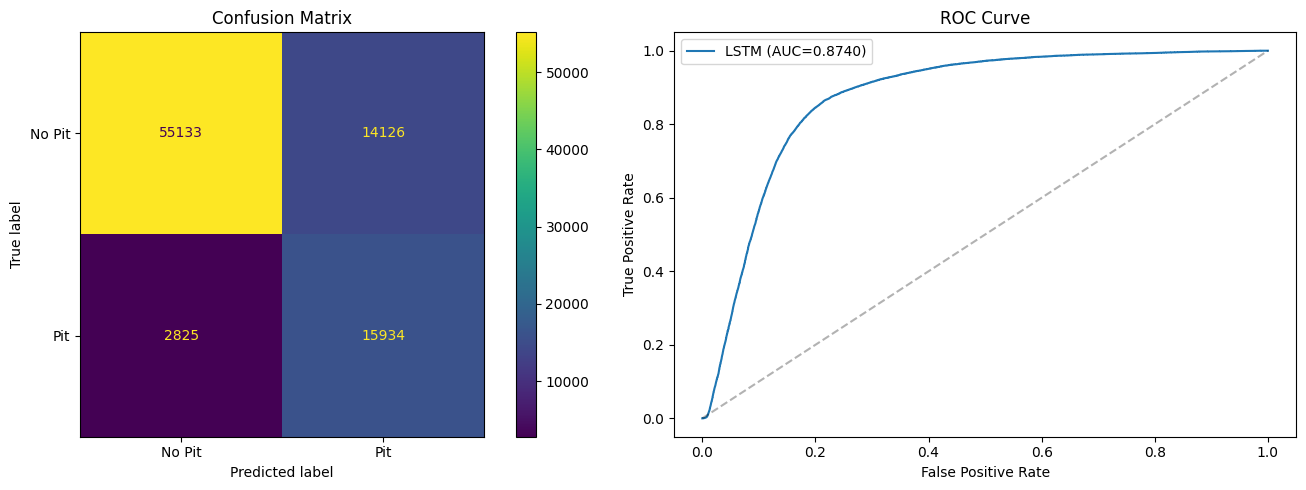

In [33]:
# Best 모델 로드 후 상세 평가
model.load_state_dict(torch.load('best_lstm.pth', weights_only=True))
auc, f1, y_true, y_pred = evaluate(model, train_loader, val_ids, device)

print(f'Best Model Validation Results:')
print(f'  AUC-ROC: {auc:.4f}')
print(f'  F1-Score: {f1:.4f}')

# Classification Report
y_pred_binary = [1 if p > 0.5 else 0 for p in y_pred]
print(f'\nClassification Report:')
print(classification_report(y_true, y_pred_binary, target_names=['No Pit', 'Pit']))

# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_true, y_pred_binary, 
                                         display_labels=['No Pit', 'Pit'], ax=axes[0])
axes[0].set_title('Confusion Matrix')

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_true, y_pred)
axes[1].plot(fpr, tpr, label=f'LSTM (AUC={auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Test 추론 및 제출 파일 생성

In [34]:
# 전체 데이터로 재학습 (train + val 모두 사용)
print('전체 train 데이터로 재학습...')
model_final = PitStopLSTM(cat_dims, cat_emb_dims, n_continuous, hidden_size=128, n_layers=2, dropout=0.3)
model_final = model_final.to(device)

# 전체 train을 학습에 사용하는 Dataset
full_train_dataset = F1SequenceDataset(combined, cat_enc_cols, cont_features)
full_train_loader = DataLoader(full_train_dataset, batch_size=128, shuffle=True, collate_fn=collate_fn)

optimizer_final = optim.AdamW(model_final.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_final = optim.lr_scheduler.CosineAnnealingLR(optimizer_final, T_max=best_epoch)

for epoch in range(best_epoch):
    loss = train_epoch(model_final, full_train_loader, optimizer_final, criterion, device)
    scheduler_final.step()
    if (epoch + 1) % 5 == 0 or epoch == best_epoch - 1:
        print(f'  Epoch {epoch+1}/{best_epoch} | Loss: {loss:.4f}')

print('재학습 완료')

전체 train 데이터로 재학습...
  Epoch 3/3 | Loss: 0.5785
재학습 완료


In [35]:
# Test 예측 추출
test_ids = set(test['id'].values)

model_final.eval()
test_predictions = {}

with torch.no_grad():
    for cats, conts, targets, masks, ids_list, lengths in full_train_loader:
        cats = cats.to(device)
        conts = conts.to(device)
        
        logits = model_final(cats, conts, lengths)
        probs = torch.sigmoid(logits)
        
        for i in range(len(lengths)):
            for t in range(lengths[i]):
                row_id = ids_list[i][t]
                if row_id in test_ids:
                    test_predictions[row_id] = probs[i, t].item()

print(f'Test 예측 수: {len(test_predictions):,} / {len(test_ids):,}')

# 제출 파일 생성
submission['PitNextLap'] = submission['id'].map(test_predictions)
print(f'Missing predictions: {submission["PitNextLap"].isna().sum()}')

submission.to_csv('submission_lstm.csv', index=False)
print(f'\n제출 파일 저장: submission_lstm.csv')
submission.head(10)

Test 예측 수: 188,165 / 188,165
Missing predictions: 0

제출 파일 저장: submission_lstm.csv


,id,PitNextLap
0,439140,0.025105
1,439141,0.059038
2,439142,0.033406
3,439143,0.566636
4,439144,0.896414
5,439145,0.332732
6,439146,0.026000
7,439147,0.022777
8,439148,0.211415
9,439149,0.013220


## 11. 예측 분포 확인

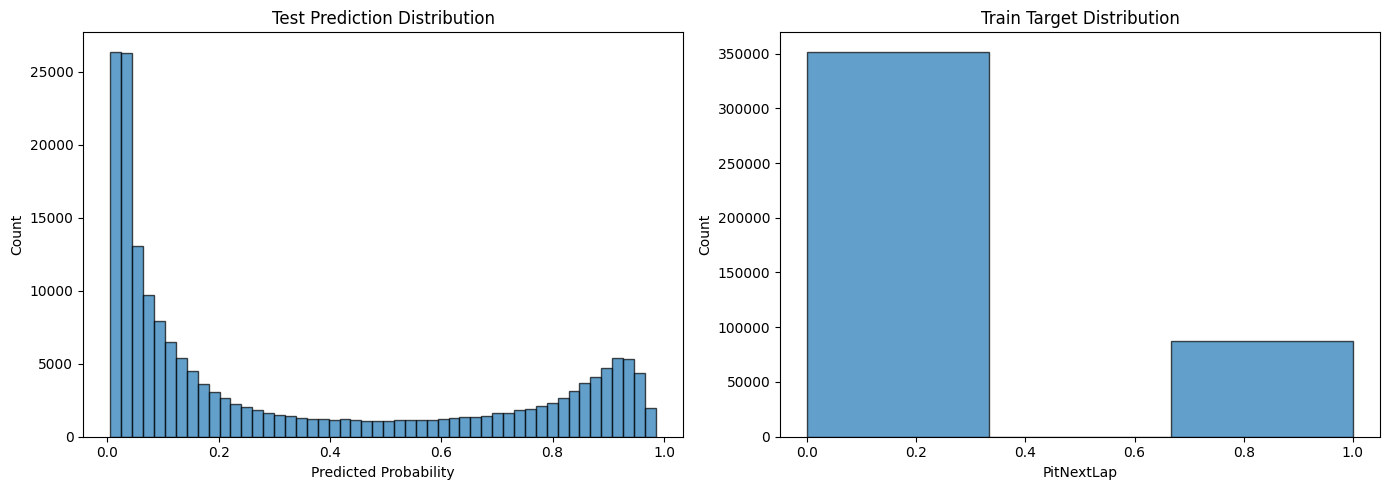

Test 예측 통계:
count    188165.000000
mean          0.329691
std           0.345496
min           0.005581
25%           0.038736
50%           0.138397
75%           0.686633
max           0.985469
Name: PitNextLap, dtype: float64


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Test 예측 분포
axes[0].hist(submission['PitNextLap'].values, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Test Prediction Distribution')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')

# Train 타겟 분포와 비교
axes[1].hist(train['PitNextLap'].values, bins=3, edgecolor='black', alpha=0.7, label='Train (actual)')
axes[1].set_title('Train Target Distribution')
axes[1].set_xlabel('PitNextLap')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Test 예측 통계:')
print(submission['PitNextLap'].describe())